<a href="https://colab.research.google.com/github/LycanVenom1225/Data-analytics-course-/blob/main/Python_Project_2_NG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [177]:
import pandas as pd
import numpy as np

df=pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')

In [178]:
df.head(20)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [222]:
dia_race=df[['race','gender','age','num_lab_procedures']]


In [238]:
dia_race['age']=dia_race['age'].str.replace(r'[^\d.]', '', regex=True)

/tmp/ipykernel_14623/1529139007.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dia_race['age']=dia_race['age'].str.replace(r'[^\d.]', '', regex=True)


In [275]:
dia_race.loc[dia_race['race']=='?','race'] = "Other"

In [276]:
dia_group=dia_race[(dia_race['age'].str.contains('4050'))]

In [277]:
dia_info=dia_group.groupby(['race','gender','age'], as_index=False)['num_lab_procedures'].sum()

In [279]:
dia_info.loc[dia_info['age']==4050,'age'] = 40-50

In [284]:
import seaborn as sns

<Axes: xlabel='race', ylabel='num_lab_procedures'>

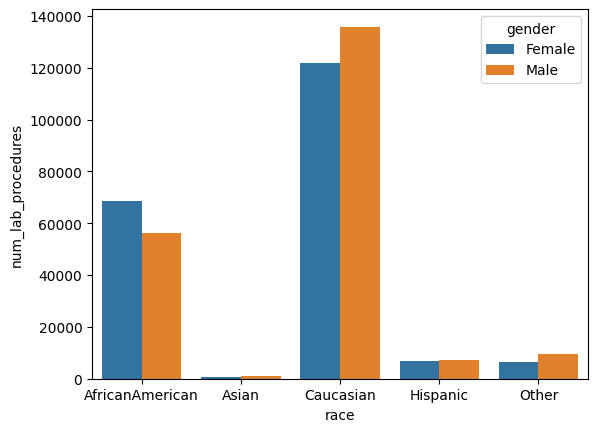

In [285]:
sns.barplot(data=dia_info, x='race', y='num_lab_procedures', hue='gender')

The data represents Lab procedures broken down by race and gender for people aged 40-50. the graph shows that Caucasian in this age demographic have more labs procudres prefommed on them than any other race by a large margin